# Bank Loan Risk Prediction

**End-to-end machine learning project for predicting loan approval from applicant and loan characteristics.**

### 1. Business Problem
- For each applicant, the bank has information such as:

- Age
- Income
- Credit score
- Employment
- Education
- Existing loans
- Loan amount
- Debt-to-income ratio
- Previous defaults
- etc

### 2. Project Objective

Our objective is:

- Build an end-to-end machine-learning system that predicts loan approval using applicant financial, demographic, and loan-related information.

- We will eventually answer questions like:
- Which factors are associated with loan approval?
- Can we predict approval for a new applicant?
- Which ML algorithm performs well on this dataset?
- How does class imbalance affect the model?
- Which features are most important?
- Can the final model be deployed?

### Project Roadmap

1. Synthetic dataset creation
2. Exploratory Data Analysis (EDA)
3. Data quality and correlation analysis
4. Feature/target preparation
5. Train/test split
6. Numerical + categorical preprocessing with `ColumnTransformer`
7. Baseline Logistic Regression, Decision Tree and Random Forest
8. XGBoost model
9. Hyperparameter tuning with 5-fold cross-validation
10. Class-imbalance handling with `scale_pos_weight`
11. Feature importance / model interpretation

> **Note:** PostgreSQL/SQL analysis and Streamlit deployment were part of the original learning roadmap but are not included in this notebook version. They can be added as separate project components later.

### 4. Create the Dataset

In [ ]:
# Import libraries 

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

### 5. Generate 100,000 Loan Applications

In [ ]:
np.random.seed(42)

n = 100000

df = pd.DataFrame({
    "Age": np.random.randint(21, 65, n),

    "Income": np.random.randint(20000, 200000, n),

    "CreditScore": np.random.randint(300, 850, n),

    "LoanAmount": np.random.randint(5000, 500000, n),

    "LoanTerm": np.random.choice(
        [12, 24, 36, 48, 60],
        size=n
    ),

    "ExistingLoans": np.random.randint(0, 6, n),

    "DTI": np.round(
        np.random.uniform(0.05, 0.70, n),
        2
    ),

    "EmploymentYears": np.random.randint(0, 31, n),

    "PreviousDefaults": np.random.randint(0, 4, n),

    "EmploymentType": np.random.choice(
        ["Salaried", "Self-Employed", "Business", "Unemployed"],
        size=n
    ),

    "Education": np.random.choice(
        ["High School", "Graduate", "Postgraduate"],
        size=n
    ),

    "HomeOwnership": np.random.choice(
        ["Rent", "Own", "Mortgage"],
        size=n
    ),

    "LoanPurpose": np.random.choice(
        ["Home", "Car", "Education", "Personal", "Business"],
        size=n
    )
})


In [ ]:
df.head()

,Age,Income,CreditScore,LoanAmount,LoanTerm,ExistingLoans,DTI,EmploymentYears,PreviousDefaults,EmploymentType,Education,HomeOwnership,LoanPurpose
0,59,154024,301,478807,48,1,0.51,19,1,Business,Postgraduate,Rent,Car
1,49,164986,501,314986,24,4,0.65,30,2,Business,Graduate,Rent,Personal
2,35,54170,615,213805,60,2,0.31,19,2,Self-Employed,Postgraduate,Own,Education
3,63,182606,825,396716,48,2,0.24,10,2,Salaried,Graduate,Mortgage,Business
4,28,137815,363,164022,48,1,0.24,24,3,Unemployed,High School,Own,Personal


In [ ]:
score = (
    0.015 * (df["CreditScore"] - 600)
    + 0.00001 * (df["Income"] - 50000)
    - 2.5 * df["DTI"]
    - 0.8 * df["PreviousDefaults"]
    - 0.3 * df["ExistingLoans"]
    + 0.03 * df["EmploymentYears"]
    - 0.000003 * df["LoanAmount"]
)

score += np.where(
    df["EmploymentType"] == "Salaried",
    0.8,
    0
)

score += np.where(
    df["EmploymentType"] == "Unemployed",
    -1.5,
    0
)

score += np.where(
    df["HomeOwnership"] == "Own",
    0.5,
    0
)

score += np.random.normal(0, 1.5, n)

In [ ]:
df["LoanStatus"] = np.where(
    score > 1,
    "Approved",
    "Rejected"
)

In [ ]:
df.head()

,Age,Income,CreditScore,LoanAmount,LoanTerm,ExistingLoans,DTI,EmploymentYears,PreviousDefaults,EmploymentType,Education,HomeOwnership,LoanPurpose,LoanStatus
0,59,154024,301,478807,48,1,0.51,19,1,Business,Postgraduate,Rent,Car,Rejected
1,49,164986,501,314986,24,4,0.65,30,2,Business,Graduate,Rent,Personal,Rejected
2,35,54170,615,213805,60,2,0.31,19,2,Self-Employed,Postgraduate,Own,Education,Rejected
3,63,182606,825,396716,48,2,0.24,10,2,Salaried,Graduate,Mortgage,Business,Approved
4,28,137815,363,164022,48,1,0.24,24,3,Unemployed,High School,Own,Personal,Rejected


### 7. Check Dataset Size

In [ ]:
df.shape

(100000, 14)

In [ ]:
# Optional: save the generated dataset locally
# df.to_csv("bank_loan_data.csv", index=False)

In [ ]:
### Reproducibility

The dataset is generated inside this notebook with `random_state = 42`, so the project can be reproduced without downloading a separate dataset.

'C:\\Users\\deepe\\Learnvista\\ML_ALGO\\Projects'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Age               100000 non-null  int32  
 1   Income            100000 non-null  int32  
 2   CreditScore       100000 non-null  int32  
 3   LoanAmount        100000 non-null  int32  
 4   LoanTerm          100000 non-null  int64  
 5   ExistingLoans     100000 non-null  int32  
 6   DTI               100000 non-null  float64
 7   EmploymentYears   100000 non-null  int32  
 8   PreviousDefaults  100000 non-null  int32  
 9   EmploymentType    100000 non-null  object 
 10  Education         100000 non-null  object 
 11  HomeOwnership     100000 non-null  object 
 12  LoanPurpose       100000 non-null  object 
 13  LoanStatus        100000 non-null  object 
dtypes: float64(1), int32(7), int64(1), object(5)
memory usage: 8.0+ MB


### 9. Check the Target Distribution

In [ ]:
df["LoanStatus"].value_counts()

LoanStatus
Rejected    88587
Approved    11413
Name: count, dtype: int64

In [ ]:
df["LoanStatus"].value_counts(normalize=True) * 100

LoanStatus
Rejected    88.587
Approved    11.413
Name: proportion, dtype: float64

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

# Phase 2 — Exploratory Data Analysis

### Now let's investigate why some applications are approved and others rejected.

### Step 1
— Target visualization

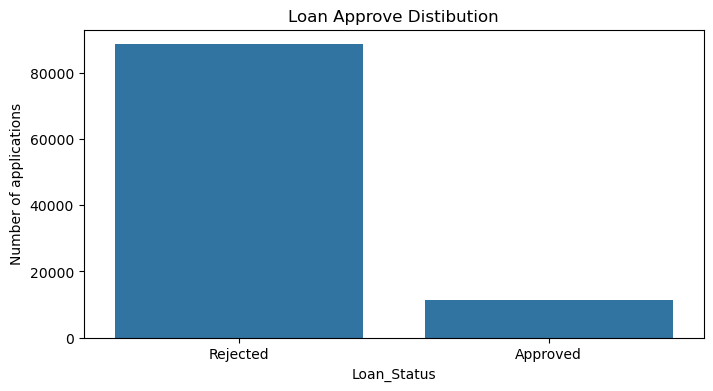

In [ ]:
plt.figure(figsize = (8,4))
sns.countplot(data = df,
              x = "LoanStatus"
             )

plt.title("Loan Approve Distibution")
plt.xlabel("Loan_Status")
plt.ylabel("Number of applications")
plt.show()

### Step 2 — Numerical summary

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,100000.0,42.541530,12.672780,21.00,32.00,43.00,53.00,64.0
Income,100000.0,109929.600880,51905.177813,20001.00,65005.00,109849.00,154846.75,199996.0
CreditScore,100000.0,574.305990,158.712999,300.00,437.00,574.00,712.00,849.0
LoanAmount,100000.0,251937.745270,142743.160112,5004.00,128424.75,251525.50,375000.50,499995.0
LoanTerm,100000.0,36.001800,16.969672,12.00,24.00,36.00,48.00,60.0
ExistingLoans,100000.0,2.500040,1.704338,0.00,1.00,3.00,4.00,5.0
DTI,100000.0,0.375214,0.187245,0.05,0.21,0.37,0.54,0.7
EmploymentYears,100000.0,14.942440,8.949616,0.00,7.00,15.00,23.00,30.0
PreviousDefaults,100000.0,1.498570,1.119880,0.00,0.00,2.00,3.00,3.0


### Step 3 — Approval rate by Credit Score

In [ ]:
df.groupby("LoanStatus")["CreditScore"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
LoanStatus,,,,
Approved,756.731359,776.0,317,849
Rejected,550.803436,543.0,300,849


In [ ]:
df.groupby("LoanStatus")["Income"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
LoanStatus,,,,
Approved,125086.172347,131254.0,20048,199996
Rejected,107976.922156,106894.0,20001,199994


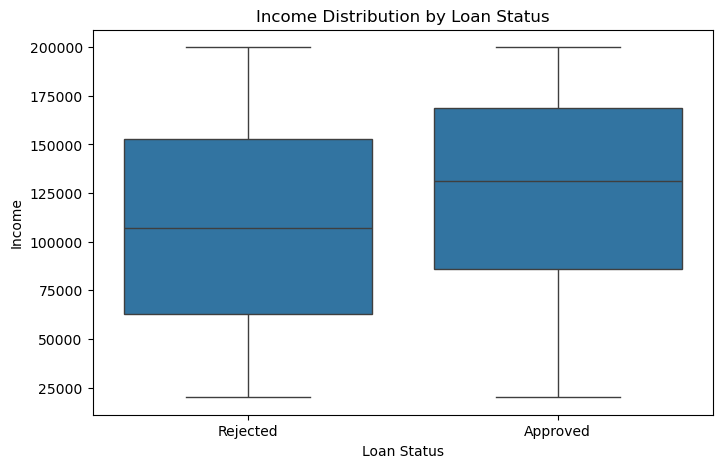

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="LoanStatus",
    y="Income"
)

plt.title("Income Distribution by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Income")

plt.show()

In [ ]:
df.groupby("LoanStatus")["DTI"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
LoanStatus,,,,
Approved,0.327897,0.30,0.05,0.7
Rejected,0.381309,0.38,0.05,0.7


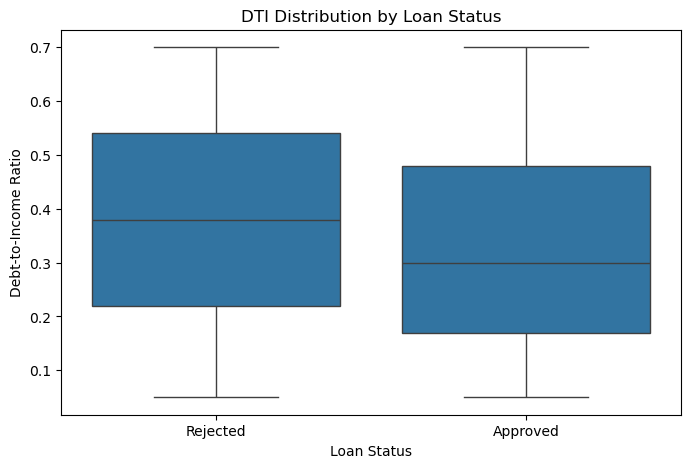

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="LoanStatus",
    y="DTI"
)

plt.title("DTI Distribution by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Debt-to-Income Ratio")

plt.show()

In [ ]:
pd.crosstab(
    df["PreviousDefaults"],
    df["LoanStatus"],
    normalize="index"
) * 100

LoanStatus,Approved,Rejected
PreviousDefaults,,
0,19.811920,80.188080
1,13.175444,86.824556
2,8.143387,91.856613
3,4.479283,95.520717


In [ ]:
pd.crosstab(
    df["EmploymentType"],
    df["LoanStatus"],
    normalize="index"
) * 100

LoanStatus,Approved,Rejected
EmploymentType,,
Business,11.728567,88.271433
Salaried,17.765868,82.234132
Self-Employed,11.691165,88.308835
Unemployed,4.434804,95.565196


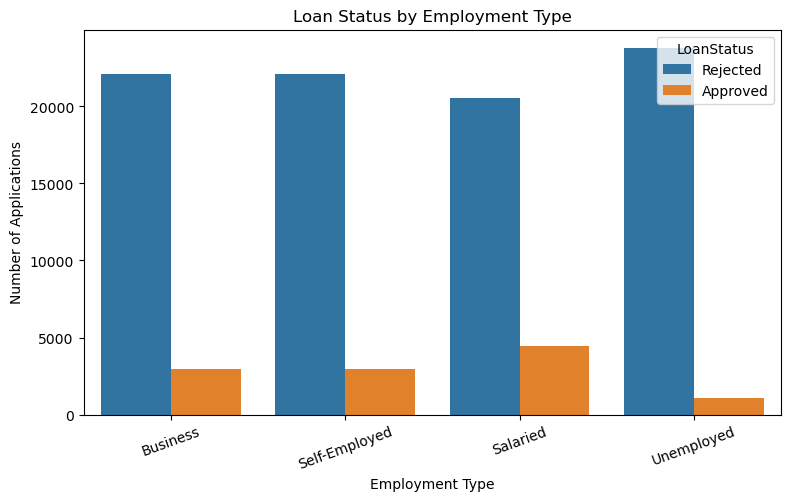

In [ ]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="EmploymentType",
    hue="LoanStatus"
)

plt.title("Loan Status by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Number of Applications")

plt.xticks(rotation=20)

plt.show()

In [ ]:
pd.crosstab(
    df["Education"],
    df["LoanStatus"],
    normalize="index"
) * 100

LoanStatus,Approved,Rejected
Education,,
Graduate,11.280790,88.719210
High School,11.505614,88.494386
Postgraduate,11.452337,88.547663


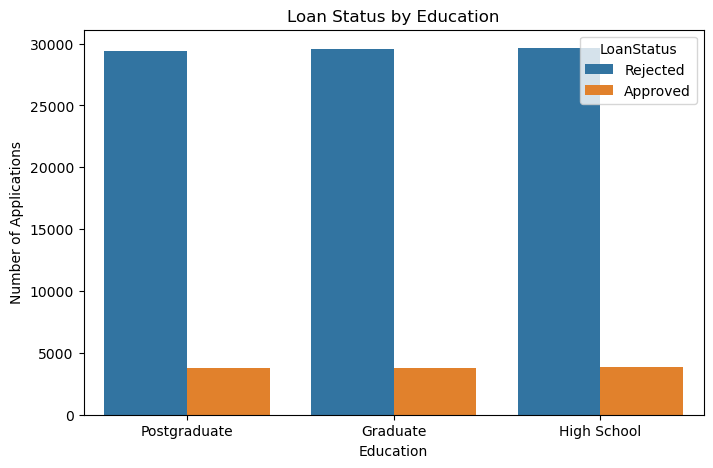

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Education",
    hue="LoanStatus"
)

plt.title("Loan Status by Education")
plt.xlabel("Education")
plt.ylabel("Number of Applications")

plt.show()

In [ ]:
pd.crosstab(
    df["HomeOwnership"],
    df["LoanStatus"],
    normalize="index"
) * 100

LoanStatus,Approved,Rejected
HomeOwnership,,
Mortgage,10.015020,89.984980
Own,13.578475,86.421525
Rent,10.634396,89.365604


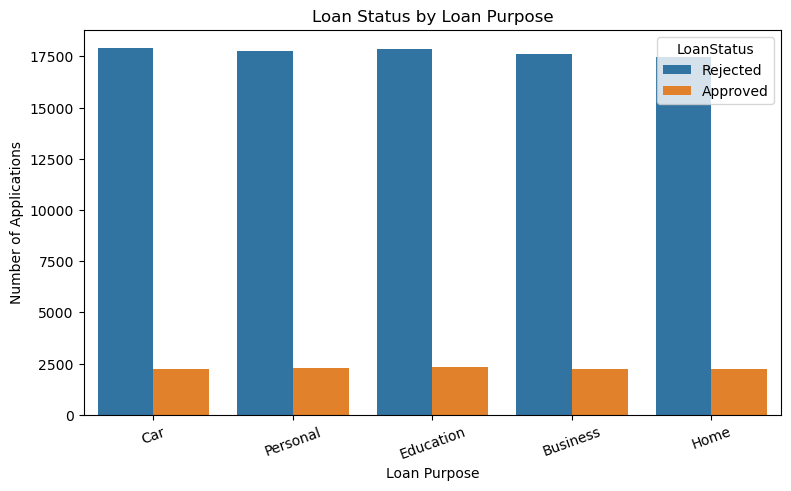

In [ ]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="LoanPurpose",
    hue="LoanStatus"
)

plt.title("Loan Status by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Number of Applications")

plt.xticks(rotation=20)

plt.show()

# Phase 3 — Outliers, Correlation & Data Preparation

### 1. First check the numerical columns

In [ ]:
numeric_col = df.select_dtypes(include = ["int32","int64","float64"]).columns 
print(numeric_col) 

Index(['Age', 'Income', 'CreditScore', 'LoanAmount', 'LoanTerm',
       'ExistingLoans', 'DTI', 'EmploymentYears', 'PreviousDefaults'],
      dtype='object')


In [ ]:
for col in numeric_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3-Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col]< lower_bound) |
        (df[col]> upper_bound)
        ]


    print(f" {col} ----------: {len(outliers)}  Outliers")
    

    

 Age ----------: 0  Outliers
 Income ----------: 0  Outliers
 CreditScore ----------: 0  Outliers
 LoanAmount ----------: 0  Outliers
 LoanTerm ----------: 0  Outliers
 ExistingLoans ----------: 0  Outliers
 DTI ----------: 0  Outliers
 EmploymentYears ----------: 0  Outliers
 PreviousDefaults ----------: 0  Outliers


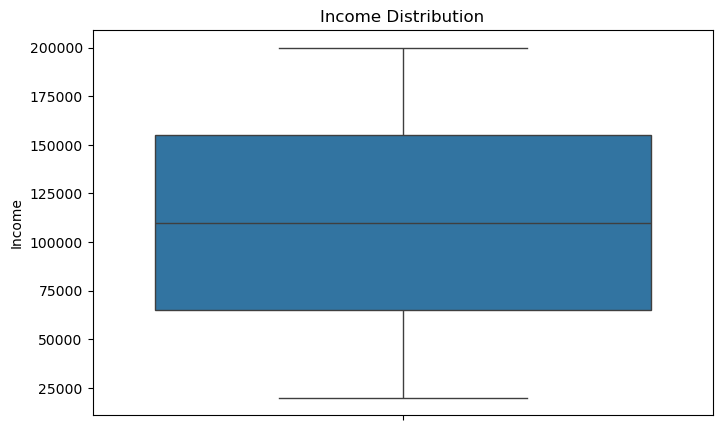

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    y="Income"
)

plt.title("Income Distribution")

plt.show()

### 4. Correlation Analysis

In [ ]:
corr_matrix = df[numeric_col].corr()

corr_matrix

,Age,Income,CreditScore,LoanAmount,LoanTerm,ExistingLoans,DTI,EmploymentYears,PreviousDefaults
Age,1.000000,0.002980,-0.000340,-0.001990,-0.000448,-0.001482,-0.001465,-0.002428,-0.004371
Income,0.002980,1.000000,0.003389,0.004295,-0.006425,-0.002949,0.001696,0.003446,0.004933
CreditScore,-0.000340,0.003389,1.000000,0.004453,-0.005335,0.001510,-0.002354,0.000235,0.001787
LoanAmount,-0.001990,0.004295,0.004453,1.000000,0.003321,0.010086,-0.001493,-0.000891,-0.002372
LoanTerm,-0.000448,-0.006425,-0.005335,0.003321,1.000000,-0.001990,0.000405,0.002272,-0.002049
ExistingLoans,-0.001482,-0.002949,0.001510,0.010086,-0.001990,1.000000,-0.000085,-0.004754,-0.001768
DTI,-0.001465,0.001696,-0.002354,-0.001493,0.000405,-0.000085,1.000000,-0.002654,0.000975
EmploymentYears,-0.002428,0.003446,0.000235,-0.000891,0.002272,-0.004754,-0.002654,1.000000,0.002184
PreviousDefaults,-0.004371,0.004933,0.001787,-0.002372,-0.002049,-0.001768,0.000975,0.002184,1.000000


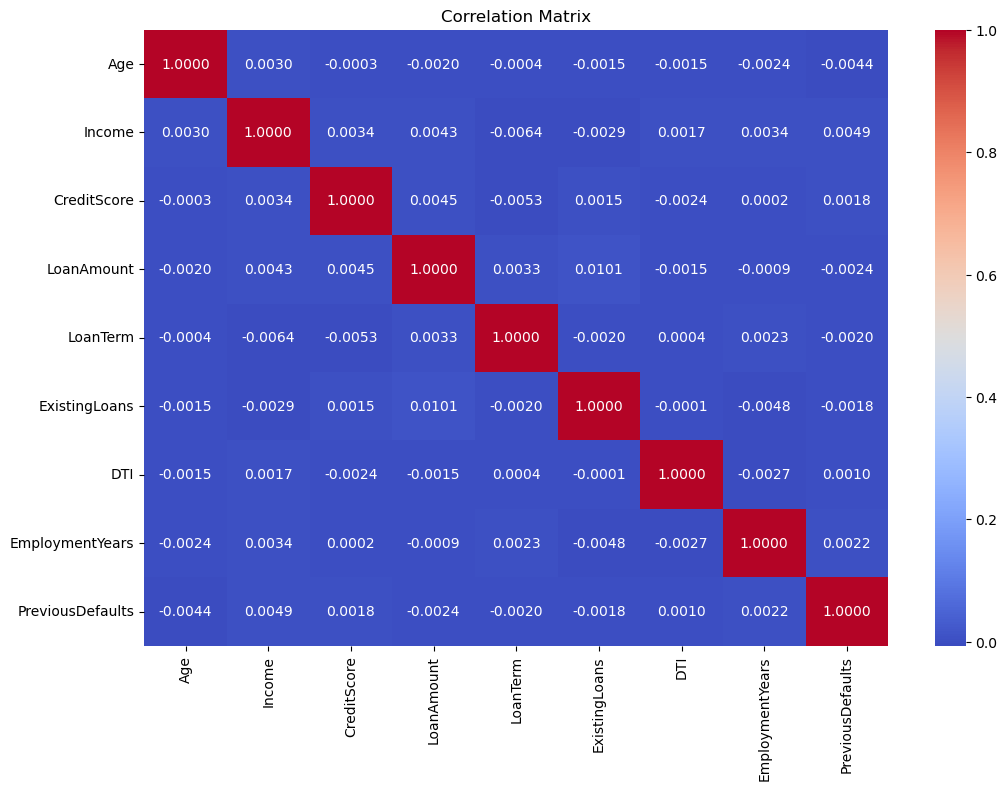

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".4f"
)

plt.title("Correlation Matrix")

plt.show()

### 5. Check correlation with the target

In [ ]:
df["LoanStatus_encoded"] = df["LoanStatus"].map({
    "Rejected": 0,
    "Approved": 1
})

In [ ]:
target_corr = (
    df[numeric_col.tolist() + ["LoanStatus_encoded"]]
    .corr()["LoanStatus_encoded"]
    .sort_values(ascending=False)
)

target_corr

LoanStatus_encoded    1.000000
CreditScore           0.412563
Income                0.104811
EmploymentYears       0.054514
LoanTerm              0.002408
Age                  -0.000535
LoanAmount           -0.083433
DTI                  -0.090702
ExistingLoans        -0.107394
PreviousDefaults     -0.179821
Name: LoanStatus_encoded, dtype: float64

In [ ]:
df.head()

,Age,Income,CreditScore,LoanAmount,LoanTerm,ExistingLoans,DTI,EmploymentYears,PreviousDefaults,EmploymentType,Education,HomeOwnership,LoanPurpose,LoanStatus,LoanStatus_encoded
0,59,154024,301,478807,48,1,0.51,19,1,Business,Postgraduate,Rent,Car,Rejected,0
1,49,164986,501,314986,24,4,0.65,30,2,Business,Graduate,Rent,Personal,Rejected,0
2,35,54170,615,213805,60,2,0.31,19,2,Self-Employed,Postgraduate,Own,Education,Rejected,0
3,63,182606,825,396716,48,2,0.24,10,2,Salaried,Graduate,Mortgage,Business,Approved,1
4,28,137815,363,164022,48,1,0.24,24,3,Unemployed,High School,Own,Personal,Rejected,0


In [ ]:
# Don't use this encoded column as a model feature.

df.drop(
    columns=["LoanStatus_encoded"],
    inplace=True
)

In [ ]:
df.head()

,Age,Income,CreditScore,LoanAmount,LoanTerm,ExistingLoans,DTI,EmploymentYears,PreviousDefaults,EmploymentType,Education,HomeOwnership,LoanPurpose,LoanStatus
0,59,154024,301,478807,48,1,0.51,19,1,Business,Postgraduate,Rent,Car,Rejected
1,49,164986,501,314986,24,4,0.65,30,2,Business,Graduate,Rent,Personal,Rejected
2,35,54170,615,213805,60,2,0.31,19,2,Self-Employed,Postgraduate,Own,Education,Rejected
3,63,182606,825,396716,48,2,0.24,10,2,Salaried,Graduate,Mortgage,Business,Approved
4,28,137815,363,164022,48,1,0.24,24,3,Unemployed,High School,Own,Personal,Rejected


### 6. Check categorical variables

In [ ]:
categoric_col = df.select_dtypes(include = ["object"]).columns
categoric_col 

Index(['EmploymentType', 'Education', 'HomeOwnership', 'LoanPurpose',
       'LoanStatus'],
      dtype='object')

### 8. Separate Features and Target

In [ ]:
X = df.drop(columns = ["LoanStatus"])
y = df["LoanStatus"]

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100000, 13)
y shape: (100000,)


### 9. Train-Test Split

In [ ]:
#We'll use 80% training and 20% testing.
#But because our target is imbalanced, we should use:
#stratify =y


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)



In [ ]:
print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (80000, 13)
Testing : (20000, 13)


# Phase 4 — Build the Preprocessing Pipeline

#### Step 1 — Define the columns

In [ ]:
numeric_features = X.select_dtypes(include = ["int32","int64","float64"]).columns
numeric_features

Index(['Age', 'Income', 'CreditScore', 'LoanAmount', 'LoanTerm',
       'ExistingLoans', 'DTI', 'EmploymentYears', 'PreviousDefaults'],
      dtype='object')

In [ ]:
categorical_features = X.select_dtypes(include = ["object"]).columns
categorical_features

Index(['EmploymentType', 'Education', 'HomeOwnership', 'LoanPurpose'], dtype='object')

### Step 2 — Import preprocessing tools

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

### Step 3 — Numerical pipeline

In [ ]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy = "median")),
    ("scaler",StandardScaler())
])

### Step 4 — Categorical pipeline

In [ ]:
categorical_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy = "most_frequent")),
    ("onehot" ,OneHotEncoder(handle_unknown = "ignore",sparse_output=False))
])                          

### Step 5 — Combine them
Now create the ColumnTransformer:

In [ ]:
preprocessor = ColumnTransformer([
    ("numeric",numeric_pipeline,numeric_features),
    ("categorical", categorical_pipeline,categorical_features )
])

In [ ]:
X_train_processed = preprocessor .fit_transform(X_train)

X_test_processed = preprocessor .transform(X_test)

### Step 7 — Check the processed dimensions

In [ ]:
print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)

print("Original X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

Original X_train shape: (80000, 13)
Processed X_train shape: (80000, 24)
Original X_test shape: (20000, 13)
Processed X_test shape: (20000, 24)


In [ ]:
preprocessor.get_feature_names_out()

array(['numeric__Age', 'numeric__Income', 'numeric__CreditScore',
       'numeric__LoanAmount', 'numeric__LoanTerm',
       'numeric__ExistingLoans', 'numeric__DTI',
       'numeric__EmploymentYears', 'numeric__PreviousDefaults',
       'categorical__EmploymentType_Business',
       'categorical__EmploymentType_Salaried',
       'categorical__EmploymentType_Self-Employed',
       'categorical__EmploymentType_Unemployed',
       'categorical__Education_Graduate',
       'categorical__Education_High School',
       'categorical__Education_Postgraduate',
       'categorical__HomeOwnership_Mortgage',
       'categorical__HomeOwnership_Own',
       'categorical__HomeOwnership_Rent',
       'categorical__LoanPurpose_Business',
       'categorical__LoanPurpose_Car',
       'categorical__LoanPurpose_Education',
       'categorical__LoanPurpose_Home',
       'categorical__LoanPurpose_Personal'], dtype=object)

# Phase 5 — Baseline Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [ ]:
logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
y_pred = logistic_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.92395

Classification Report:
              precision    recall  f1-score   support

    Approved       0.72      0.55      0.62      2283
    Rejected       0.94      0.97      0.96     17717

    accuracy                           0.92     20000
   macro avg       0.83      0.76      0.79     20000
weighted avg       0.92      0.92      0.92     20000


Confusion Matrix:
[[ 1257  1026]
 [  495 17222]]


In [ ]:
y_train_pred_lr = logistic_model.predict(X_train)

In [ ]:
print(accuracy_score(y_train, y_train_pred_lr))

0.923675


# Phase 6 — Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

In [ ]:
decision_tree_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
y_pred_dt = decision_tree_model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.8818

Classification Report:
              precision    recall  f1-score   support

    Approved       0.48      0.51      0.50      2283
    Rejected       0.94      0.93      0.93     17717

    accuracy                           0.88     20000
   macro avg       0.71      0.72      0.71     20000
weighted avg       0.88      0.88      0.88     20000


Confusion Matrix:
[[ 1160  1123]
 [ 1241 16476]]


In [ ]:
y_train_pred_dt = decision_tree_model.predict(X_train)

print("Decision Tree Training Accuracy:",
      accuracy_score(y_train, y_train_pred_dt))

print("Decision Tree Testing Accuracy:",
      accuracy_score(y_test, y_pred_dt))

Decision Tree Training Accuracy: 1.0
Decision Tree Testing Accuracy: 0.8818


# Phase 7 — Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

In [ ]:
random_forest_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
y_pred_rf  = random_forest_model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.92095

Classification Report:
              precision    recall  f1-score   support

    Approved       0.77      0.44      0.56      2283
    Rejected       0.93      0.98      0.96     17717

    accuracy                           0.92     20000
   macro avg       0.85      0.71      0.76     20000
weighted avg       0.91      0.92      0.91     20000


Confusion Matrix:
[[ 1011  1272]
 [  309 17408]]


In [ ]:
# check overfitting

y_train_pred_rf = random_forest_model.predict(X_train)

print("Random Forest Training Accuracy:",
      accuracy_score(y_train, y_train_pred_rf))

print("Random Forest Testing Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Random Forest Training Accuracy: 1.0
Random Forest Testing Accuracy: 0.92095


# Class imbalance

#### Let's test this first with Logistic Regression

In [ ]:
logistic_balanced_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [ ]:
logistic_balanced_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
y_pred_log_balanced = logistic_balanced_model.predict(X_test)

In [ ]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_log_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_balanced))

Accuracy: 0.85945

Classification Report:
              precision    recall  f1-score   support

    Approved       0.44      0.90      0.59      2283
    Rejected       0.99      0.85      0.91     17717

    accuracy                           0.86     20000
   macro avg       0.71      0.88      0.75     20000
weighted avg       0.92      0.86      0.88     20000


Confusion Matrix:
[[ 2060   223]
 [ 2588 15129]]


In [ ]:
# check overfitting

y_train_pred_log_balanced  =  logistic_balanced_model.predict(X_train)

print("logistic_balanced Training Accuracy:",
      accuracy_score(y_train, y_train_pred_log_balanced))

print("logistic_balanced Testing Accuracy:",
      accuracy_score(y_test, y_pred_log_balanced ))

logistic_balanced Training Accuracy: 0.85805
logistic_balanced Testing Accuracy: 0.85945


### Let's test with Random Forest

In [ ]:
random_balanced_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=1
    ))
])

In [ ]:
random_balanced_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
y_pred_rand_balanced = random_balanced_model.predict(X_test)

In [ ]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_rand_balanced ))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rand_balanced ))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rand_balanced ))

Accuracy: 0.9174

Classification Report:
              precision    recall  f1-score   support

    Approved       0.78      0.39      0.52      2283
    Rejected       0.93      0.99      0.95     17717

    accuracy                           0.92     20000
   macro avg       0.85      0.69      0.74     20000
weighted avg       0.91      0.92      0.90     20000


Confusion Matrix:
[[  880  1403]
 [  249 17468]]


In [ ]:
y_train_pred_rand_balanced   =  random_balanced_model.predict(X_train)

print("Random_balanced Training Accuracy:",
      accuracy_score(y_train, y_train_pred_rand_balanced ))

print("Random_balanced Testing Accuracy:",
      accuracy_score(y_test, y_pred_rand_balanced))

Random_balanced Training Accuracy: 1.0
Random_balanced Testing Accuracy: 0.9174


# Phase 8 — XGBoost

In [ ]:
import xgboost as xgb

In [ ]:
print(xgb.__version__)

3.4.1


### We already have X_train and X_test.

In [ ]:
#encoded the y_train and y_test

y_train_encoded = y_train.map({
    "Rejected": 0,
    "Approved": 1
})

y_test_encoded = y_test.map({
    "Rejected": 0,
    "Approved": 1
})




In [ ]:
y_train_encoded.value_counts()

LoanStatus
0    70870
1     9130
Name: count, dtype: int64

In [ ]:
y_test_encoded.value_counts()

LoanStatus
0    17717
1     2283
Name: count, dtype: int64

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=1
    ))
])

In [ ]:
xgb_model.fit(X_train,y_train_encoded)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
print("Accuracy:",
      accuracy_score(y_test_encoded, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(
    y_test_encoded,
    y_pred_xgb,
    target_names=["Rejected", "Approved"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test_encoded,
    y_pred_xgb
))

Accuracy: 0.9212

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.94      0.97      0.96     17717
    Approved       0.70      0.55      0.61      2283

    accuracy                           0.92     20000
   macro avg       0.82      0.76      0.78     20000
weighted avg       0.92      0.92      0.92     20000


Confusion Matrix:
[[17175   542]
 [ 1034  1249]]


In [ ]:
y_train_pred_xgb = xgb_model.predict(X_train)

print("XGBoost Training Accuracy:",
      accuracy_score(y_train_encoded, y_train_pred_xgb))

print("XGBoost Testing Accuracy:",
      accuracy_score(y_test_encoded, y_pred_xgb))

XGBoost Training Accuracy: 0.942575
XGBoost Testing Accuracy: 0.9212


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [3, 5],
    "classifier__learning_rate": [0.05, 0.1]
}

In [ ]:
xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=1,
    verbose=1
)

In [ ]:
xgb_grid.fit(X_train, y_train_encoded)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'classifier__learning_rate': [0.05, 0.1], 'classifier__max_depth': [3, 5], 'classifier__n_estimators': [100, 200]}"
,scoring,'f1_macro'
,n_jobs,1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numeric', ...), ('categorical', ...)]"


In [ ]:
print("Best Parameters:")
print(xgb_grid.best_params_)

print("\nBest CV Score:")
print(xgb_grid.best_score_)


Best Parameters:
{'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 200}

Best CV Score:
0.7845946125991099


In [ ]:
#Get the best XGBoost model

best_xgb_model = xgb_grid.best_estimator_

In [ ]:
best_xgb_model

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

In [ ]:
print("Tuned XGBoost Accuracy:",
      accuracy_score(y_test_encoded, y_pred_xgb_tuned))

print("\nClassification Report:")
print(classification_report(
    y_test_encoded,
    y_pred_xgb_tuned,
    target_names=["Rejected", "Approved"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test_encoded,
    y_pred_xgb_tuned
))

Tuned XGBoost Accuracy: 0.92145

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.94      0.97      0.96     17717
    Approved       0.70      0.54      0.61      2283

    accuracy                           0.92     20000
   macro avg       0.82      0.76      0.78     20000
weighted avg       0.92      0.92      0.92     20000


Confusion Matrix:
[[17188   529]
 [ 1042  1241]]


In [ ]:
y_train_pred_xgb_tuned = best_xgb_model.predict(X_train)
print("train_Tuned XGBoost Accuracy:",
      accuracy_score(y_train_encoded, y_train_pred_xgb_tuned ))
print("test_Tuned XGBoost Accuracy:",
      accuracy_score(y_test_encoded, y_pred_xgb_tuned))

train_Tuned XGBoost Accuracy: 0.9341625
test_Tuned XGBoost Accuracy: 0.92145


# XGBoost + class imbalance now.

In [ ]:
# scale_pos_weight

### Step 1 — Calculate the class ratio

In [ ]:
negative = (y_train_encoded == 0).sum()
positive = (y_train_encoded == 1).sum()

scale_ratio = negative / positive

print("Rejected:", negative)
print("Approved:", positive)
print("Scale Pos Weight:", scale_ratio)

Rejected: 70870
Approved: 9130
Scale Pos Weight: 7.762322015334064


### Step 2 — Create XGBoost with class weighting

In [ ]:
xgb_imbalance = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=1
    ))
])

### Step 3 — GridSearch only scale_pos_weight

In [ ]:
imbalance_grid = {
    "classifier__scale_pos_weight": [1, 2, 4, 8]
}

In [ ]:
xgb_imbalance_grid = GridSearchCV(
    estimator=xgb_imbalance,
    param_grid=imbalance_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=1,
    verbose=1
)

In [ ]:
xgb_imbalance_grid.fit(
    X_train,
    y_train_encoded
)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'classifier__scale_pos_weight': [1, 2, ...]}"
,scoring,'f1_macro'
,n_jobs,1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numeric', ...), ('categorical', ...)]"


In [ ]:
print("Best Parameters:")
print(xgb_imbalance_grid.best_params_)

print("\nBest CV Macro F1:")
print(xgb_imbalance_grid.best_score_)

Best Parameters:
{'classifier__scale_pos_weight': 2}

Best CV Macro F1:
0.7982485768028134


In [ ]:
best_xgb_imbalance = xgb_imbalance_grid.best_estimator_

In [ ]:
y_pred_xgb_imbalance = best_xgb_imbalance.predict(X_test)

In [ ]:
print(
    "XGBoost with Class Weight Accuracy:",
    accuracy_score(y_test_encoded, y_pred_xgb_imbalance)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test_encoded,
        y_pred_xgb_imbalance,
        target_names=["Rejected", "Approved"]
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_encoded,
        y_pred_xgb_imbalance
    )
)

XGBoost with Class Weight Accuracy: 0.9144

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.96      0.94      0.95     17717
    Approved       0.61      0.69      0.65      2283

    accuracy                           0.91     20000
   macro avg       0.78      0.82      0.80     20000
weighted avg       0.92      0.91      0.92     20000


Confusion Matrix:
[[16705  1012]
 [  700  1583]]


In [ ]:
y_train_pred_xgb_imbalance = best_xgb_imbalance.predict(X_train)

print(
    "Training Accuracy:",
    accuracy_score(
        y_train_encoded,
        y_train_pred_xgb_imbalance
    )
)

print(
    "Testing Accuracy:",
    accuracy_score(
        y_test_encoded,
        y_pred_xgb_imbalance
    )
)

Training Accuracy: 0.9272375
Testing Accuracy: 0.9144


In [ ]:
feature_names = best_xgb_imbalance.named_steps[
    "preprocessor"
].get_feature_names_out()

In [ ]:
feature_names

array(['numeric__Age', 'numeric__Income', 'numeric__CreditScore',
       'numeric__LoanAmount', 'numeric__LoanTerm',
       'numeric__ExistingLoans', 'numeric__DTI',
       'numeric__EmploymentYears', 'numeric__PreviousDefaults',
       'categorical__EmploymentType_Business',
       'categorical__EmploymentType_Salaried',
       'categorical__EmploymentType_Self-Employed',
       'categorical__EmploymentType_Unemployed',
       'categorical__Education_Graduate',
       'categorical__Education_High School',
       'categorical__Education_Postgraduate',
       'categorical__HomeOwnership_Mortgage',
       'categorical__HomeOwnership_Own',
       'categorical__HomeOwnership_Rent',
       'categorical__LoanPurpose_Business',
       'categorical__LoanPurpose_Car',
       'categorical__LoanPurpose_Education',
       'categorical__LoanPurpose_Home',
       'categorical__LoanPurpose_Personal'], dtype=object)

In [ ]:
xgb_classifier = best_xgb_imbalance.named_steps["classifier"]
importance = xgb_classifier.feature_importances_
importance

array([0.01142139, 0.03363496, 0.26670232, 0.02632691, 0.01119781,
       0.05972092, 0.03020852, 0.02108816, 0.13720974, 0.0113532 ,
       0.07166662, 0.01029274, 0.1571504 , 0.00947986, 0.0110667 ,
       0.01060436, 0.01867603, 0.03431151, 0.01311001, 0.01095779,
       0.01355339, 0.01015732, 0.00978061, 0.01032879], dtype=float32)

In [ ]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

In [ ]:
feature_importance_df

,Feature,Importance
0,numeric__Age,0.011421
1,numeric__Income,0.033635
2,numeric__CreditScore,0.266702
3,numeric__LoanAmount,0.026327
4,numeric__LoanTerm,0.011198
5,numeric__ExistingLoans,0.059721
6,numeric__DTI,0.030209
7,numeric__EmploymentYears,0.021088
8,numeric__PreviousDefaults,0.137210
9,categorical__EmploymentType_Business,0.011353


In [ ]:
# Sort feature importance and visualize the top 10 features

top_features = (
    feature_importance_df
    .sort_values("Importance", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Project Summary

### Key findings

- The generated dataset contains **100,000 loan applications** and the target is strongly imbalanced: **88.587% Rejected** vs **11.413% Approved**.
- Baseline Logistic Regression achieved **92.395% accuracy**, with **0.55 recall** for Approved applications.
- The tuned XGBoost model achieved **92.145% test accuracy** before class-imbalance weighting.
- Optimizing XGBoost `scale_pos_weight` selected **2** using 5-fold cross-validation with macro F1 as the scoring metric.
- The class-weighted XGBoost model achieved **0.69 recall** and **0.65 F1-score** for Approved applications, with **91.44% test accuracy**.
- Feature importance shows **CreditScore** as the largest feature importance in the final XGBoost model, followed by features including **PreviousDefaults** and **EmploymentType_Unemployed**.

### Portfolio takeaway

This project demonstrates an end-to-end classification workflow: synthetic data generation, EDA, preprocessing pipelines, baseline modeling, XGBoost tuning, class-imbalance handling, and feature-importance analysis.